# Grammar scoring from speech clips

SHL hiring assessment 2026. The task is to predict a grammar score from 0 to 5 for speech clips of 45 to 60 seconds (769 for training, 216 for testing). The leaderboard uses RMSE and Pearson correlation.

What I ended up with: take out the noise clips with a simple rule, transcribe with Whisper, turn each transcript into BERT and RoBERTa features from the middle layers, fit ridge regression on those, fine-tune RoBERTa as a second model, and average the two. The things that did not help (GPT-2 features, pause features) are in `experiments.ipynb`.

The notebook runs top to bottom on a Kaggle GPU. Transcripts are saved to csv, so running the transcription cell again is quick if the files are already there.

In [1]:
import os, time, random, warnings
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import torch
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, RepeatedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from transformers import (AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

DATA = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"
output_dir = "/kaggle/working"
NOISE_THRESHOLD = 0.87
BERT, ROBERTA = "bert-base-uncased", "roberta-base" 


def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))


print("numpy", np.__version__, "| pandas", pd.__version__, "| torch", torch.__version__)
print("GPU available:", torch.cuda.is_available())

numpy 2.1.3 | pandas 2.3.3 | torch 2.11.0+cu128
GPU available: True


## 1. Data

Scores go from 0 to 5 in half-point steps. Guessing the mean for every clip gives an RMSE of about 1.24. The rubric only defines scores 1 to 5, but 37 clips are labelled 0, so I looked at those next.

769 training clips
count    769.000
mean       3.313
std        1.239
min        0.000
25%        2.500
50%        3.000
75%        4.000
max        5.000
Name: label, dtype: float64
mean-baseline RMSE, all clips: 1.238


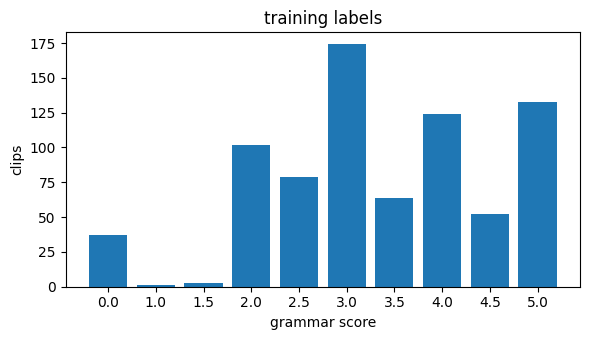

In [2]:
train = pd.read_csv(os.path.join(DATA, "train.csv"))
print(train.shape[0], "training clips")
print(train["label"].describe().round(3))

y_all = train["label"].values            # all clips, including the ones labelled 0
print("mean-baseline RMSE, all clips:", round(y_all.std(), 3))

counts = train["label"].value_counts().sort_index()
plt.figure(figsize=(6, 3.5))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("grammar score"); plt.ylabel("clips"); plt.title("training labels")
plt.tight_layout(); plt.show()

## 2. The clips labelled 0

I listened to one of them and it is only noise, no speech at all. A real recording has pauses, so only about 44% of a speech clip is above a small amplitude floor, while the label-0 clips are around 93%. One threshold of 0.87 on that number splits all 769 training clips correctly.

The gap is small though (highest speech clip 0.863, lowest label-0 clip 0.871), so I checked the test set as well. Only one test clip goes over the threshold and the next highest is 0.806, which is inside the normal speech range. That one clip gets a score of 0 in the final predictions, and every model is trained on the speech clips only.

In [3]:
def audio_stats(split, fn):
    wav, sr = librosa.load(os.path.join(DATA, split, fn), sr=16000)
    # duration, rms loudness, share of samples above a 0.01 amplitude floor
    return len(wav) / sr, float(np.sqrt(np.mean(wav ** 2))), float((np.abs(wav) > 0.01).mean())


test = pd.read_csv(os.path.join(DATA, "test.csv"))
assert len(test) == 216, len(test)      # test.csv is what gets scored

train[["dur_s", "rms", "frac_active"]] = [audio_stats("train", f) for f in train["filename"]]
test[["dur_s", "rms", "frac_active"]] = [audio_stats("test", f) for f in test["filename"]]
train["is_zero"] = train["label"] == 0
train["rule_fires"] = train["frac_active"] > NOISE_THRESHOLD
test["is_noise"] = test["frac_active"] > NOISE_THRESHOLD

print(train.groupby("is_zero")[["dur_s", "rms", "frac_active"]].agg(["mean", "min", "max"]).round(3).T)
print()
print(pd.crosstab(train["is_zero"], train["rule_fires"], rownames=["label is 0"], colnames=["rule fires"]))
print("highest speech clip:", round(train.loc[~train["is_zero"], "frac_active"].max(), 3),
      "| lowest label-0 clip:", round(train.loc[train["is_zero"], "frac_active"].min(), 3))
print()
print(int(test["is_noise"].sum()), "of", len(test), "test clips over the threshold")
print("top test values:", test["frac_active"].sort_values(ascending=False).head(5).round(3).tolist())

is_zero            False   True 
dur_s       mean  55.676  57.864
            min   20.060  24.128
            max   61.040  61.035
rms         mean   0.058   0.122
            min    0.004   0.067
            max    0.186   0.169
frac_active mean   0.444   0.928
            min    0.027   0.871
            max    0.863   0.952

rule fires  False  True 
label is 0              
False         732      0
True            0     37
highest speech clip: 0.863 | lowest label-0 clip: 0.871

1 of 216 test clips over the threshold
top test values: [0.898, 0.806, 0.804, 0.787, 0.786]


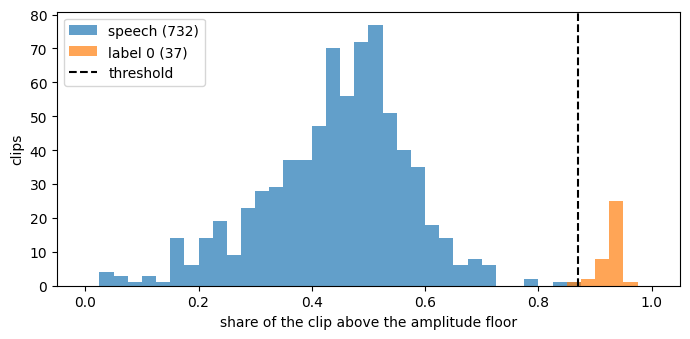

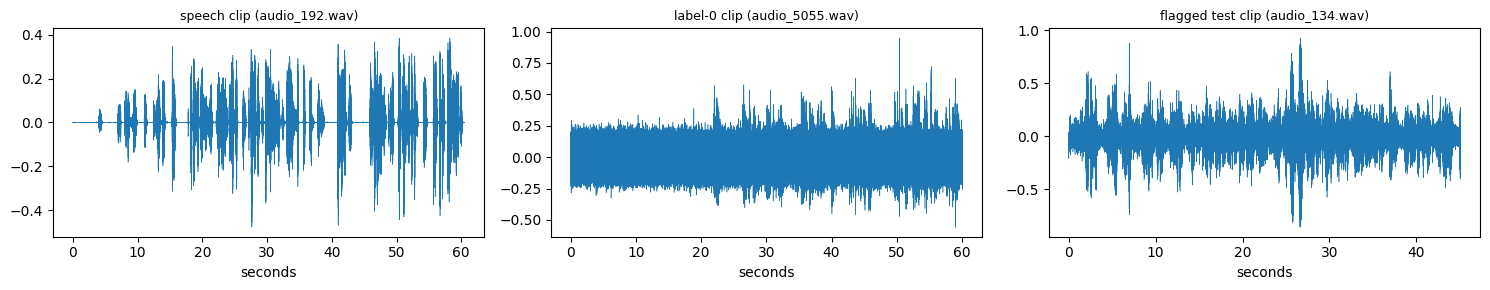

In [4]:
n_speech, n_zero = int((~train["is_zero"]).sum()), int(train["is_zero"].sum())

fig, ax = plt.subplots(figsize=(7, 3.5))
bins = np.linspace(0, 1, 41)
ax.hist(train.loc[~train["is_zero"], "frac_active"], bins=bins, alpha=0.7, label=f"speech ({n_speech})")
ax.hist(train.loc[train["is_zero"], "frac_active"], bins=bins, alpha=0.7, label=f"label 0 ({n_zero})")
ax.axvline(NOISE_THRESHOLD, color="k", ls="--", label="threshold")
ax.set_xlabel("share of the clip above the amplitude floor"); ax.set_ylabel("clips")
ax.legend(); plt.tight_layout(); plt.show()

examples = [("speech clip", "train", train.loc[~train["is_zero"], "filename"].iloc[0]),
            ("label-0 clip", "train", train.loc[train["is_zero"], "filename"].iloc[0])]
flagged = test.loc[test["is_noise"], "filename"]
if len(flagged):
    examples.append(("flagged test clip", "test", flagged.iloc[0]))

fig, axes = plt.subplots(1, len(examples), figsize=(5 * len(examples), 3))
for ax, (title, split, fn) in zip(np.atleast_1d(axes), examples):
    wav, sr = librosa.load(os.path.join(DATA, split, fn), sr=16000)
    ax.plot(np.arange(len(wav)) / sr, wav, lw=0.4)
    ax.set_title(f"{title} ({fn})", fontsize=9); ax.set_xlabel("seconds")
plt.tight_layout(); plt.show()

## 3. Transcripts

Whisper (small model, through faster-whisper) with the voice filter on and the language fixed to English. The function saves to csv every 25 clips and carries on from the file if it is run again, because this step takes a while.

In the few transcripts I read, the speakers' grammar mistakes were still there, which is what the later steps need. Whisper also makes its own recognition mistakes, and the models cannot tell those apart from the speaker's.

In [5]:
!pip install -q faster-whisper
from faster_whisper import WhisperModel

device = "cuda" if torch.cuda.is_available() else "cpu"
whisper = WhisperModel("small", device=device, compute_type="float16" if device == "cuda" else "int8")


def transcribe(path):
    # I load the audio with librosa and pass the array in. Letting faster-whisper open the
    # file itself failed here with a PyAV error.
    audio, _ = librosa.load(path, sr=16000, mono=True)
    segs, _ = whisper.transcribe(audio, language="en", vad_filter=True, beam_size=1)
    segs = list(segs)
    text = " ".join(s.text.strip() for s in segs)
    nsp = sum(s.no_speech_prob for s in segs) / max(len(segs), 1)
    return text, nsp


def process_split(split, save_every=25):
    split_dir = os.path.join(DATA, split)
    out_path = os.path.join(output_dir, f"{split}_transcriptions.csv")
    files = sorted(f for f in os.listdir(split_dir)
                   if f.lower().endswith((".wav", ".mp3", ".flac", ".m4a", ".ogg")))

    results = []
    if os.path.exists(out_path):                       # carry on from the saved file
        prev = pd.read_csv(out_path)
        prev = prev[prev["no_speech_prob"].notna()]    # failed ones get tried again
        results = prev.to_dict("records")
    done = {r["filename"] for r in results}
    todo = [f for f in files if f not in done]
    print(f"{split}: {len(done)} done, {len(todo)} to do")

    t0 = time.time()
    for i, fn in enumerate(todo, 1):
        try:
            text, nsp = transcribe(os.path.join(split_dir, fn))
            results.append({"filename": fn, "text": text, "no_speech_prob": nsp})
        except Exception as e:
            print("failed:", fn, e)
            results.append({"filename": fn, "text": "", "no_speech_prob": None})
        if i % save_every == 0:
            pd.DataFrame(results).to_csv(out_path, index=False)
            print(f"{i}/{len(todo)}, {(time.time() - t0) / i:.1f} s per clip")
    pd.DataFrame(results).to_csv(out_path, index=False)
    return pd.DataFrame(results)


tr_txt = process_split("train")
te_txt = process_split("test")
for name, df in [("train", tr_txt), ("test", te_txt)]:
    assert df["no_speech_prob"].notna().all(), f"{name}: some transcriptions failed, run this cell again"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 61.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 53.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 80.0 MB/s eta 0:00:00:00:0100:01


train: 0 done, 769 to do
25/769, 0.7 s per clip
50/769, 0.7 s per clip
75/769, 0.7 s per clip
100/769, 0.7 s per clip
125/769, 0.7 s per clip
150/769, 0.7 s per clip
175/769, 0.7 s per clip
200/769, 0.7 s per clip
225/769, 0.7 s per clip
250/769, 0.7 s per clip
275/769, 0.7 s per clip
300/769, 0.7 s per clip
325/769, 0.7 s per clip
350/769, 0.7 s per clip
375/769, 0.7 s per clip
400/769, 0.7 s per clip
425/769, 0.7 s per clip
450/769, 0.8 s per clip
475/769, 0.8 s per clip
500/769, 0.8 s per clip
525/769, 0.8 s per clip
550/769, 0.8 s per clip
575/769, 0.8 s per clip
600/769, 0.8 s per clip
625/769, 0.8 s per clip
650/769, 0.8 s per clip
675/769, 0.8 s per clip
700/769, 0.8 s per clip
725/769, 0.8 s per clip
750/769, 0.8 s per clip
test: 0 done, 216 to do
25/216, 0.7 s per clip
50/216, 0.7 s per clip
75/216, 0.6 s per clip
100/216, 0.6 s per clip
125/216, 0.6 s per clip
150/216, 0.7 s per clip
175/216, 0.7 s per clip
200/216, 0.7 s per clip


In [6]:
tr_txt, te_txt = tr_txt.fillna({"text": ""}), te_txt.fillna({"text": ""})

# training set: speech clips only
real = train.merge(tr_txt, on="filename")
real = real[~real["is_zero"]].reset_index(drop=True)
assert len(real) == n_speech, (len(real), n_speech)     # nothing lost in the merge
y = real["label"].values
print(len(real), "speech clips | mean label", round(y.mean(), 3), "| mean-baseline RMSE", round(y.std(), 3))

# test set, same order as test.csv
te = test[["filename", "is_noise"]].merge(te_txt, on="filename", how="left").fillna({"text": ""})
assert len(te) == 216 and te["filename"].is_unique
assert (te["filename"].values == test["filename"].values).all()
short = te["text"].str.split().str.len() < 10
print("test clips with fewer than 10 words:", te.loc[short, "filename"].tolist())

732 speech clips | mean label 3.481 | mean-baseline RMSE 1.014
test clips with fewer than 10 words: ['audio_107.wav']


## 4. BERT and RoBERTa features

For each transcript I take the hidden states from every layer of the model, average them over the tokens, and get one vector per layer. Instead of just using the last layer I scored every layer on its own (ridge regression, 5-fold CV repeated twice), since the last layer is not always the best one for grammar-type information.

In [7]:
mk = lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(0, 4, 13)))


def cv_oof(model_fn, X, y, n_rep=3, seed=0):
    # repeated 5-fold CV. Returns the first repetition's predictions and the
    # RMSE / Pearson averaged over the repetitions.
    rkf = RepeatedKFold(n_splits=5, n_repeats=n_rep, random_state=seed)
    oof = np.zeros((n_rep, len(y)))
    for i, (tr, va) in enumerate(rkf.split(X)):
        oof[i // 5, va] = np.clip(model_fn().fit(X[tr], y[tr]).predict(X[va]), 0, 5)
    r = np.mean([rmse(y, o) for o in oof])
    p = np.mean([pearsonr(y, o)[0] for o in oof])
    return oof[0], r, p


@torch.no_grad()
def layer_embeddings(path, texts, max_len=512, bs=16, half=True):
    tok = AutoTokenizer.from_pretrained(path)
    mdl = AutoModel.from_pretrained(path, output_hidden_states=True).to("cuda").eval()
    if half:
        mdl = mdl.half()
    out = []
    for i in range(0, len(texts), bs):
        b = tok(texts[i:i + bs], return_tensors="pt", padding=True,
                truncation=True, max_length=max_len).to("cuda")
        hs = mdl(**b).hidden_states                              # input embeddings + every layer
        m = b["attention_mask"].unsqueeze(-1).to(hs[0].dtype)
        out.append(torch.stack([(h * m).sum(1) / m.sum(1) for h in hs], 1).float().cpu().numpy())
    del mdl
    torch.cuda.empty_cache()
    return np.concatenate(out)


texts = real["text"].tolist()
E_bert = layer_embeddings(BERT, texts)
E_rob = layer_embeddings(ROBERTA, texts)
for name, E in [("bert", E_bert), ("roberta", E_rob)]:
    assert np.isfinite(E).all(), f"NaN in the {name} embeddings"
    np.save(os.path.join(output_dir, f"E_{name}_train.npy"), E)
print(E_bert.shape, E_rob.shape)       # clips x 13 (input embeddings + 12 layers) x 768

(732, 13, 768) (732, 13, 768)


        bert         roberta        
        rmse pearson    rmse pearson
layer                               
0      0.774   0.646   0.769   0.652
1      0.777   0.643   0.732   0.692
2      0.767   0.654   0.710   0.714
3      0.744   0.680   0.691   0.732
4      0.727   0.697   0.675   0.747
5      0.706   0.717   0.653   0.766
6      0.687   0.736   0.637   0.778
7      0.665   0.754   0.636   0.779
8      0.650   0.768   0.635   0.779
9      0.655   0.764   0.639   0.776
10     0.661   0.758   0.635   0.780
11     0.662   0.757   0.640   0.776
12     0.669   0.751   0.649   0.769


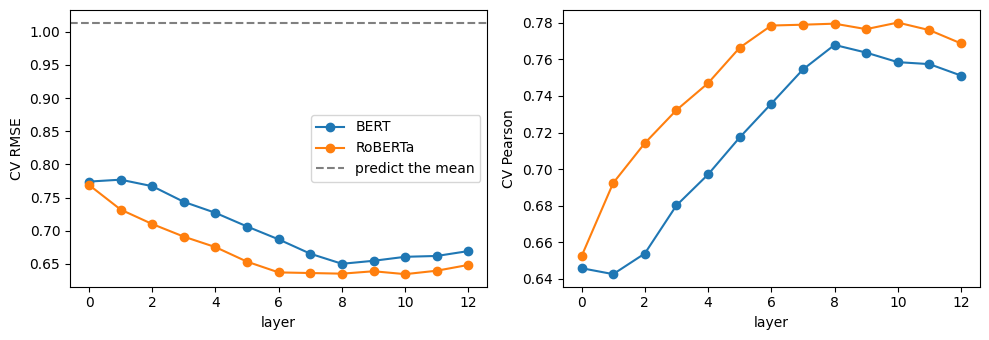

In [8]:
def scan_layers(E, n_rep=2):
    rows = [(L,) + cv_oof(mk, E[:, L], y, n_rep=n_rep)[1:] for L in range(E.shape[1])]
    return pd.DataFrame(rows, columns=["layer", "rmse", "pearson"])


scan_bert, scan_rob = scan_layers(E_bert), scan_layers(E_rob)
print(pd.concat({"bert": scan_bert.set_index("layer"), "roberta": scan_rob.set_index("layer")}, axis=1).round(3))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
for name, s in [("BERT", scan_bert), ("RoBERTa", scan_rob)]:
    ax[0].plot(s["layer"], s["rmse"], marker="o", label=name)
    ax[1].plot(s["layer"], s["pearson"], marker="o", label=name)
ax[0].axhline(y.std(), color="gray", ls="--", label="predict the mean")
ax[0].set_xlabel("layer"); ax[0].set_ylabel("CV RMSE"); ax[0].legend()
ax[1].set_xlabel("layer"); ax[1].set_ylabel("CV Pearson")
plt.tight_layout(); plt.show()

BERT is best around layer 8 (CV RMSE 0.650, against 0.669 for the last layer). RoBERTa is flat from layer 6 to 11 at about 0.635 and does better than BERT overall. Even layer 0, which is only the word embeddings with no context, gets about 0.77 (guessing the mean gives 1.0), so a lot of the score seems to come from which words and phrases the speaker uses and not only from sentence structure.

The best layer was picked on the same CV, so I used the average of a few neighbouring layers (7 to 10 for BERT, 6 to 10 for RoBERTa) and not the single best one.

## 5. Putting the two encoders together

In [9]:
cands = {
    "BERT, last layer": E_bert[:, 12],
    "BERT, layer 8": E_bert[:, 8],
    "BERT, mean of layers 7-10": E_bert[:, 7:11].mean(1),
    "RoBERTa, mean of layers 6-10": E_rob[:, 6:11].mean(1),
    "BERT 7-10 and RoBERTa 6-10, concatenated": np.hstack([E_bert[:, 7:11].mean(1), E_rob[:, 6:11].mean(1)]),
}
rows, oofs = [], {}
for name, X in cands.items():
    oofs[name], r, p = cv_oof(mk, X, y, n_rep=3)
    rows.append((name, r, p))

print("mean-baseline RMSE:", round(y.std(), 3))
print(pd.DataFrame(rows, columns=["features", "CV RMSE", "CV Pearson"]).round(3).to_string(index=False))

# two separate ridge models, one per encoder, predictions averaged
ens = np.mean([oofs["BERT, mean of layers 7-10"], oofs["RoBERTa, mean of layers 6-10"]], axis=0)
print("\naverage of the two ridge models (first repetition only): RMSE", round(rmse(y, ens), 3),
      "| Pearson", round(pearsonr(y, ens)[0], 3))

mean-baseline RMSE: 1.014
                                features  CV RMSE  CV Pearson
                        BERT, last layer    0.669       0.752
                           BERT, layer 8    0.650       0.768
               BERT, mean of layers 7-10    0.653       0.766
            RoBERTa, mean of layers 6-10    0.635       0.780
BERT 7-10 and RoBERTa 6-10, concatenated    0.625       0.788

average of the two ridge models (first repetition only): RMSE 0.624 | Pearson 0.79


RoBERTa alone gets 0.635. Concatenating the BERT and RoBERTa features gets 0.625, and averaging two separate ridge models (one per encoder) gives about the same, so I went with the average because it is easier to explain. Differences under 0.01 are probably noise here, since the same model moves by about that much between CV splits.

## 6. Fine-tuning RoBERTa

roberta-base with a one-number regression head, trained with MSE on standardised scores. 4 epochs, learning rate 2e-5, batch size 16, 5-fold CV. Each fold model also predicts the test set and those 5 predictions are averaged. The frozen-feature ensemble is scored on the same folds so the two can be compared fairly.

In [10]:
from torch.utils.data import DataLoader, Dataset

MODEL, MAXLEN, BS, EPOCHS, LR = ROBERTA, 384, 16, 4, 2e-5
dev = "cuda"
tok = AutoTokenizer.from_pretrained(MODEL)

tr_texts, te_texts = real["text"].tolist(), te["text"].tolist()
y_mu, y_sd = y.mean(), y.std()
y_z = ((y - y_mu) / y_sd).astype(np.float32)          # train on standardised scores


class DS(Dataset):
    def __init__(self, texts, ys=None):
        self.enc, self.ys = tok(texts, truncation=True, max_length=MAXLEN), ys

    def __len__(self):
        return len(self.enc["input_ids"])

    def __getitem__(self, i):
        d = {k: v[i] for k, v in self.enc.items()}
        if self.ys is not None:
            d["labels"] = float(self.ys[i])
        return d


def collate(batch):
    labels = [b.pop("labels") for b in batch] if "labels" in batch[0] else None
    out = tok.pad(batch, return_tensors="pt")
    if labels is not None:
        out["labels"] = torch.tensor(labels, dtype=torch.float32)
    return out


@torch.no_grad()
def predict(model, ds):
    model.eval()
    out = []
    for b in DataLoader(ds, batch_size=32, collate_fn=collate):
        b = {k: v.to(dev) for k, v in b.items() if k != "labels"}
        with torch.autocast("cuda", dtype=torch.float16):
            out.append(model(**b).logits.squeeze(-1).float().cpu().numpy())
    return np.concatenate(out)


def train_fold(tr_idx, seed):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=1).to(dev)
    dl = DataLoader(DS([tr_texts[i] for i in tr_idx], y_z[tr_idx]), batch_size=BS,
                    shuffle=True, collate_fn=collate)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    steps = EPOCHS * len(dl)
    sch = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)
    scaler = torch.amp.GradScaler("cuda")
    for ep in range(EPOCHS):
        model.train()
        for b in dl:
            b = {k: v.to(dev) for k, v in b.items()}
            labels = b.pop("labels")
            with torch.autocast("cuda", dtype=torch.float16):
                pred = model(**b).logits.squeeze(-1)
            loss = torch.nn.functional.mse_loss(pred.float(), labels)
            opt.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update(); sch.step()
    return model


kf = KFold(5, shuffle=True, random_state=0)
te_ds = DS(te_texts)
oof_ft, test_ft = np.zeros(len(y)), np.zeros((5, len(te_texts)))
fit_rmse = []                                         # RMSE of each fold model on its own training part
for f, (tr_i, va_i) in enumerate(kf.split(tr_texts)):
    m = train_fold(tr_i, seed=f)
    oof_ft[va_i] = predict(m, DS([tr_texts[i] for i in va_i])) * y_sd + y_mu
    test_ft[f] = predict(m, te_ds) * y_sd + y_mu
    seen = np.clip(predict(m, DS([tr_texts[i] for i in tr_i])) * y_sd + y_mu, 0, 5)
    fit_rmse.append(rmse(y[tr_i], seen))
    print(f"fold {f}: validation RMSE {rmse(y[va_i], np.clip(oof_ft[va_i], 0, 5)):.3f}"
          f" | training RMSE {fit_rmse[-1]:.3f}")
    del m
    torch.cuda.empty_cache()

oof_ft = np.clip(oof_ft, 0, 5)
test_ft = np.clip(test_ft.mean(0), 0, 5)
print(f"\nfine-tuned: out-of-fold RMSE {rmse(y, oof_ft):.3f} | Pearson {pearsonr(y, oof_ft)[0]:.3f}"
      f" | training RMSE (mean of the folds) {np.mean(fit_rmse):.3f}")

# frozen ensemble on the same folds
Xb, Xr = E_bert[:, 7:11].mean(1), E_rob[:, 6:11].mean(1)
oof_fz = np.zeros(len(y))
for tr_i, va_i in kf.split(Xb):
    oof_fz[va_i] = np.mean([np.clip(mk().fit(X[tr_i], y[tr_i]).predict(X[va_i]), 0, 5)
                            for X in (Xb, Xr)], axis=0)
print(f"frozen ensemble: out-of-fold RMSE {rmse(y, oof_fz):.3f} | Pearson {pearsonr(y, oof_fz)[0]:.3f}")

for w in [0.3, 0.5, 0.7]:
    b = w * oof_ft + (1 - w) * oof_fz
    print(f"blend, weight on fine-tuned = {w}: RMSE {rmse(y, b):.3f} | Pearson {pearsonr(y, b)[0]:.3f}")

fold 0: validation RMSE 0.597 | training RMSE 0.442
fold 1: validation RMSE 0.636 | training RMSE 0.412
fold 2: validation RMSE 0.670 | training RMSE 0.435
fold 3: validation RMSE 0.567 | training RMSE 0.404
fold 4: validation RMSE 0.660 | training RMSE 0.420

fine-tuned: out-of-fold RMSE 0.627 | Pearson 0.796 | training RMSE (mean of the folds) 0.423
frozen ensemble: out-of-fold RMSE 0.624 | Pearson 0.790
blend, weight on fine-tuned = 0.3: RMSE 0.607 | Pearson 0.802
blend, weight on fine-tuned = 0.5: RMSE 0.604 | Pearson 0.804
blend, weight on fine-tuned = 0.7: RMSE 0.608 | Pearson 0.803


Fine-tuned alone it is about level with the frozen ensemble on RMSE (0.632 against 0.624) but has a higher Pearson, and the folds vary quite a lot (0.56 to 0.69). Averaging the two helps more than either one alone (0.603). The weight hardly matters between 0.3 and 0.7, so I kept 0.5 and did not tune it on 732 clips.

## 7. Final predictions

Test features for both encoders, ridge fitted on all the speech clips, then a 50/50 average with the fine-tuned predictions. Clips over the noise threshold get 0.

In [11]:
SPECS = {"bert": (BERT, slice(7, 11)), "roberta": (ROBERTA, slice(6, 11))}
E_train = {"bert": E_bert, "roberta": E_rob}

frozen_tr, frozen_te = [], []
for name, (path, sl) in SPECS.items():
    E_te = layer_embeddings(path, te["text"].tolist())
    assert np.isfinite(E_te).all()
    np.save(os.path.join(output_dir, f"E_{name}_test.npy"), E_te)
    Xtr_m, Xte_m = E_train[name][:, sl].mean(1), E_te[:, sl].mean(1)
    m = mk().fit(Xtr_m, y)
    frozen_tr.append(np.clip(m.predict(Xtr_m), 0, 5))
    frozen_te.append(np.clip(m.predict(Xte_m), 0, 5))
frozen_tr, frozen_te = np.mean(frozen_tr, axis=0), np.mean(frozen_te, axis=0)

print("training RMSE, frozen ensemble:", round(rmse(y, frozen_tr), 3))
print("training RMSE, fine-tuned (mean of the folds):", round(float(np.mean(fit_rmse)), 3))
blend_oof = np.clip(0.5 * oof_ft + 0.5 * oof_fz, 0, 5)
print("out-of-fold RMSE, blend:", round(rmse(y, blend_oof), 3), "| Pearson:", round(pearsonr(y, blend_oof)[0], 3))
print("correlation between the two models on the test clips:", round(pearsonr(frozen_te, test_ft)[0], 3))

pred = np.clip(0.5 * frozen_te + 0.5 * test_ft, 0, 5)
pred[te["is_noise"].values] = 0.0

sub = pd.DataFrame({"filename": te["filename"], "label": pred})
assert len(sub) == 216 and sub["filename"].is_unique
assert set(sub["filename"]) == set(test["filename"])
assert sub["label"].notna().all() and sub["label"].between(0, 5).all()
print("predictions: mean", round(sub["label"].mean(), 3), "| std", round(sub["label"].std(), 3))
sub.to_csv(os.path.join(output_dir, "submission.csv"), index=False)

training RMSE, frozen ensemble: 0.517
training RMSE, fine-tuned (mean of the folds): 0.423
out-of-fold RMSE, blend: 0.604 | Pearson: 0.804
correlation between the two models on the test clips: 0.95
predictions: mean 3.311 | std 0.833


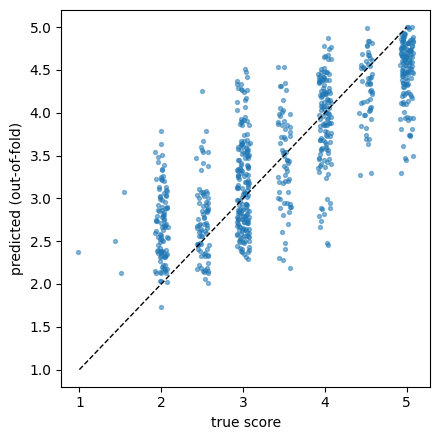

In [12]:
# out-of-fold predictions against the real scores (small jitter so the half-points do not stack)
rng = np.random.default_rng(0)
plt.figure(figsize=(4.5, 4.5))
plt.scatter(y + rng.uniform(-0.08, 0.08, len(y)), blend_oof, s=8, alpha=0.5)
plt.plot([1, 5], [1, 5], "k--", lw=1)
plt.xlabel("true score"); plt.ylabel("predicted (out-of-fold)")
plt.tight_layout(); plt.show()

In [13]:
# files that submit_offline.ipynb needs (upload these as a Kaggle dataset)
np.save(os.path.join(output_dir, "y_train.npy"), y)
te[["filename", "is_noise"]].to_csv(os.path.join(output_dir, "test_meta.csv"), index=False)
np.save(os.path.join(output_dir, "oof_ft.npy"), oof_ft)
np.save(os.path.join(output_dir, "test_ft.npy"), test_ft)

need = ["E_bert_train.npy", "E_bert_test.npy", "E_roberta_train.npy", "E_roberta_test.npy",
        "y_train.npy", "test_meta.csv", "oof_ft.npy", "test_ft.npy"]
print("missing:", [f for f in need if not os.path.exists(os.path.join(output_dir, f))])

missing: []


## Results

All numbers are on the 732 speech clips, with 5-fold CV. The rows for ridge on one encoder are averaged over 3 repeats of the folds. The average of the two ridge models, the fine-tuned model and the blend each come from one split, so compare those with a bit of care. A re-run can shift the third decimal.

| model | RMSE | Pearson |
|---|---|---|
| predict the mean | 0.998 | n/a |
| BERT, last layer | 0.669 | 0.751 |
| BERT, layer 8 | 0.650 | 0.768 |
| BERT, mean of layers 7-10 | 0.653 | 0.766 |
| RoBERTa, mean of layers 6-10 | 0.635 | 0.780 |
| BERT and RoBERTa concatenated | 0.625 | 0.788 |
| average of the two ridge models | 0.624 | 0.790 |
| RoBERTa fine-tuned | 0.632 | 0.797 |
| final blend (50/50) | 0.603 | 0.806 |

Training RMSE of the frozen ensemble is 0.517. The fine-tuned model's training RMSE is printed in section 6. On the leaderboard (216 test clips) the frozen ensemble alone scored 0.399 and the final blend 0.393.

## What did not help

GPT-2 surprise features and pause / speech-rate features gave no gain in CV on top of the BERT features, so I dropped them. The code is in `experiments.ipynb`.

## Limitations

Whisper's recognition mistakes go straight into the features. The test set is only 216 clips, so the leaderboard score moves a little with small changes. The noise rule is a hand-picked threshold with a thin margin on the training set. Fine-tuning changes a bit from run to run. The scored Kaggle notebook had no internet, so the features and fine-tuned predictions from this notebook were saved and loaded in `submit_offline.ipynb`.